# 🔍  Network Anomaly Detection Pipeline

**Project**: AI-Augmented Observability System for ISP  
**Model**: LSTM Autoencoder (Unsupervised Anomaly Detection)  
**Dataset**: CESNET Time Series 24

---

## 📋 Pipeline Overview

1. **Load Data** - Read NPZ matrix with proper column labels
2. **Preprocess** - Log transform, normalize skewed features
3. **Create Windows** - Sliding windows for temporal patterns
4. **Train Model** - LSTM Autoencoder learns "normal" patterns
5. **Detect Anomalies** - High reconstruction error = anomaly
6. **Visualize** - Charts for presentation

## 1️⃣ Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

## 2️⃣ Define Column Names (Reference for NPZ)

In [ ]:
# Column names in order for your NPZ files
COLUMN_NAMES = [
    'id_time', 'n_flows', 'n_packets', 'n_bytes',
    'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn',
    'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports',
    'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip',
    'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
    'dir_ratio_packets', 'dir_ratio_bytes',
    'avg_duration', 'avg_ttl', 'ip_id'
]

# Feature indices (columns 1-18, excluding id_time and ip_id)
FEATURE_INDICES = list(range(1, 19))  # Columns 1 to 18
FEATURE_NAMES = COLUMN_NAMES[1:-1]

print(f"Total columns: {len(COLUMN_NAMES)}")
print(f"Feature columns for training: {len(FEATURE_NAMES)}")

Total columns: 20
Feature columns for training: 18


## 3️⃣ Load NPZ Data

In [ ]:
# Path to your NPZ file
NPZ_PATH = r"C:\Users\bharg\OneDrive\Desktop\Major_Project\CESNET\institution_subnets\agg_1_day\npz\institutions_subnets_1day_merged_single.npz"

# Load the data
print("Loading NPZ file...")
npz_data = np.load(NPZ_PATH, allow_pickle=True)
print(f"Keys in NPZ: {list(npz_data.keys())}")

# Get the matrix
try:
    matrix = npz_data['full_matrix']
except KeyError:
    matrix = npz_data['arr_0']

# Convert to float32
matrix = matrix.astype(np.float32)

print(f"\n✅ Data loaded!")
print(f"Shape: {matrix.shape}")
print(f"Rows (samples): {matrix.shape[0]:,}")
print(f"Columns (features): {matrix.shape[1]}")

Loading NPZ file...
Keys in NPZ: ['full_matrix']

✅ Data loaded!
Shape: (150408, 20)
Rows (samples): 150,408
Columns (features): 20


## 4️⃣ Data Visualization (EDA) - Using NPZ Directly

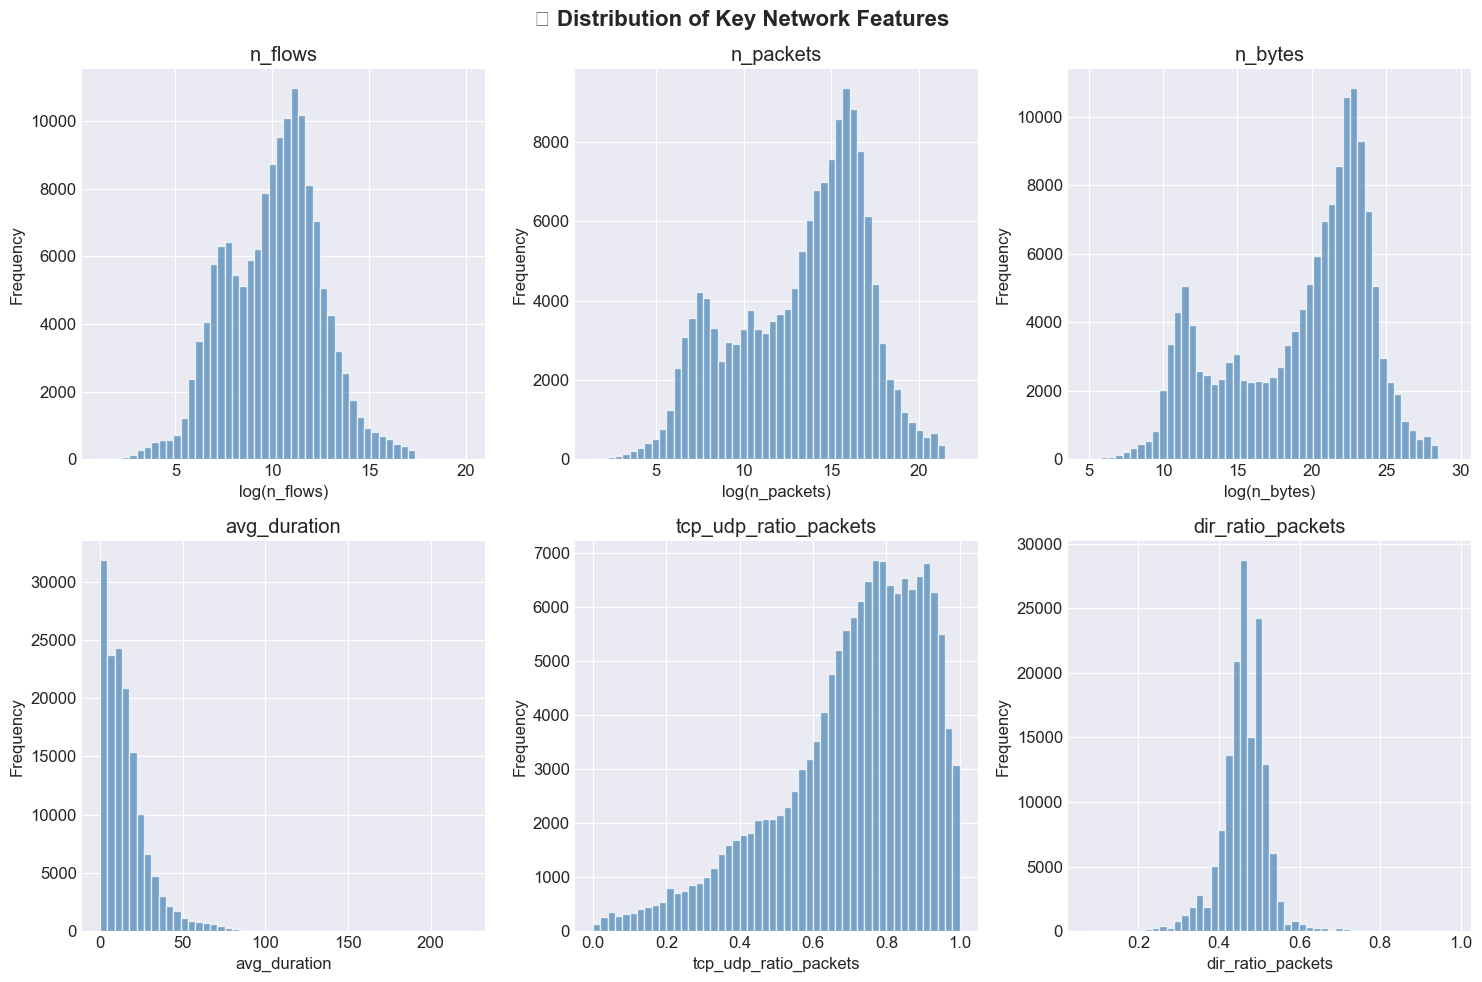

✅ Saved: visualization_1_distributions.png


In [ ]:
# Visualization 1: Distribution of key features (using numpy array directly)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Distribution of Key Network Features', fontsize=16, fontweight='bold')

# Feature indices: n_flows=1, n_packets=2, n_bytes=3, avg_duration=17, tcp_udp_ratio_packets=13, dir_ratio_packets=15
features_to_plot = [(1, 'n_flows'), (2, 'n_packets'), (3, 'n_bytes'), 
                    (17, 'avg_duration'), (13, 'tcp_udp_ratio_packets'), (15, 'dir_ratio_packets')]

for idx, (col_idx, feature_name) in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = matrix[:, col_idx]
    
    # Use log scale for highly skewed features
    if feature_name in ['n_flows', 'n_packets', 'n_bytes']:
        data = np.log1p(data)
        ax.set_xlabel(f'log({feature_name})')
    else:
        ax.set_xlabel(feature_name)
    
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature_name}')

plt.tight_layout()
plt.savefig('visualization_1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_1_distributions.png")

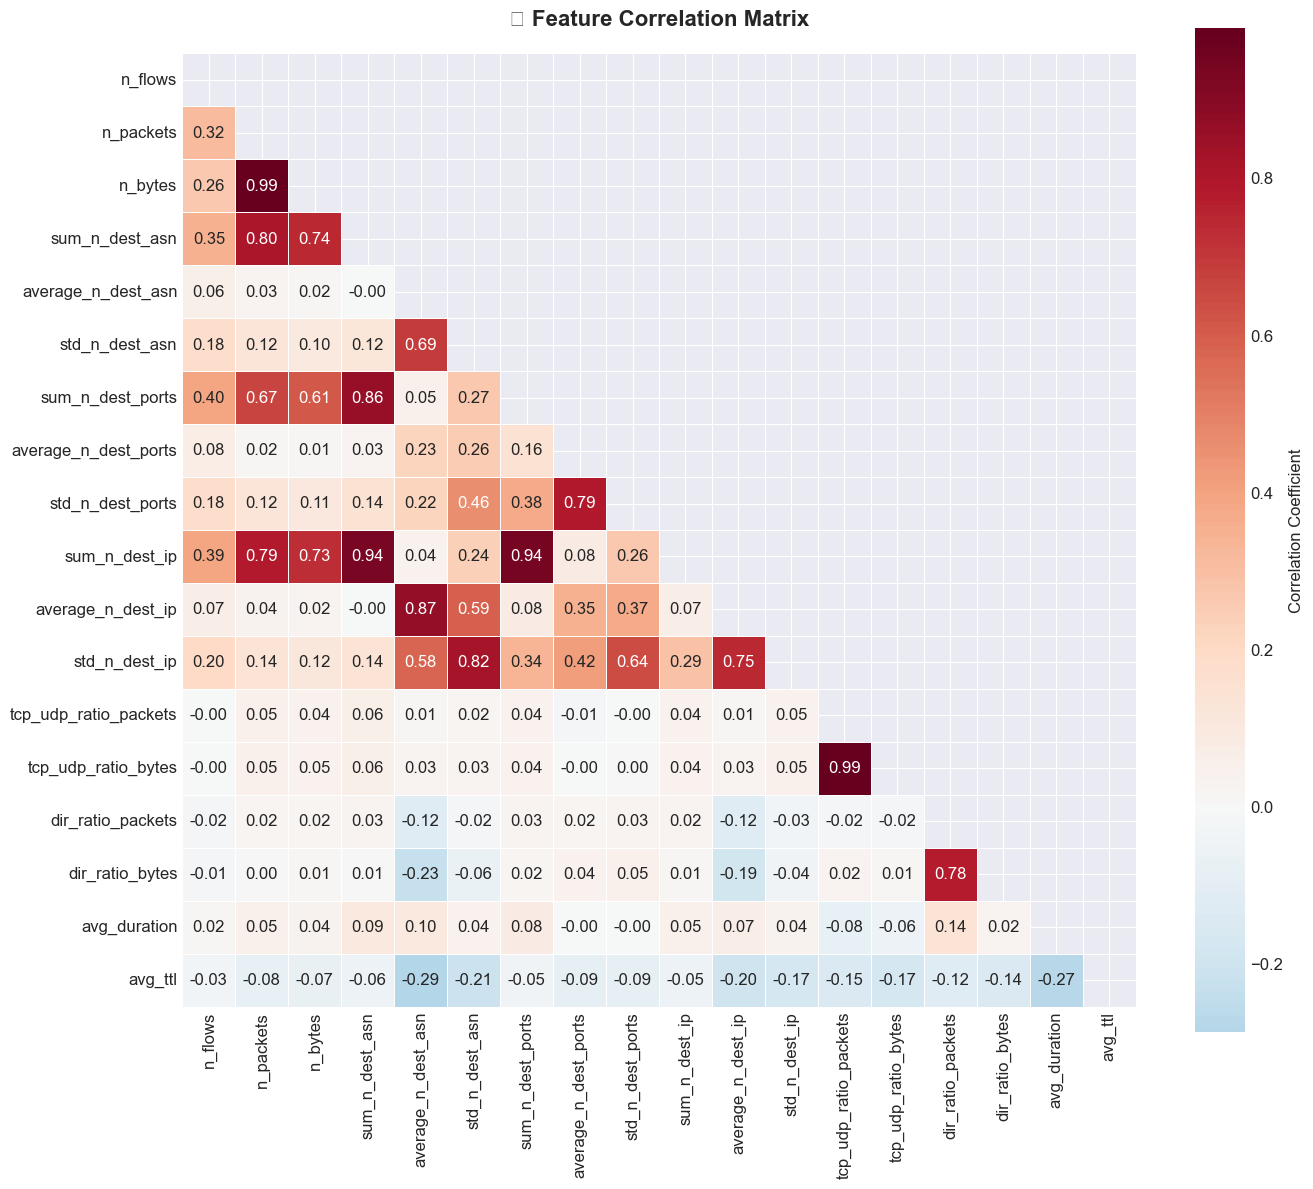

✅ Saved: visualization_2_correlation.png


In [ ]:
# Visualization 2: Correlation Heatmap (using numpy)
plt.figure(figsize=(14, 12))

# Extract features and compute correlation
features_matrix = matrix[:, 1:-1]  # All features except id_time and ip_id
correlation_matrix = np.corrcoef(features_matrix.T)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('🔗 Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualization_2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_2_correlation.png")

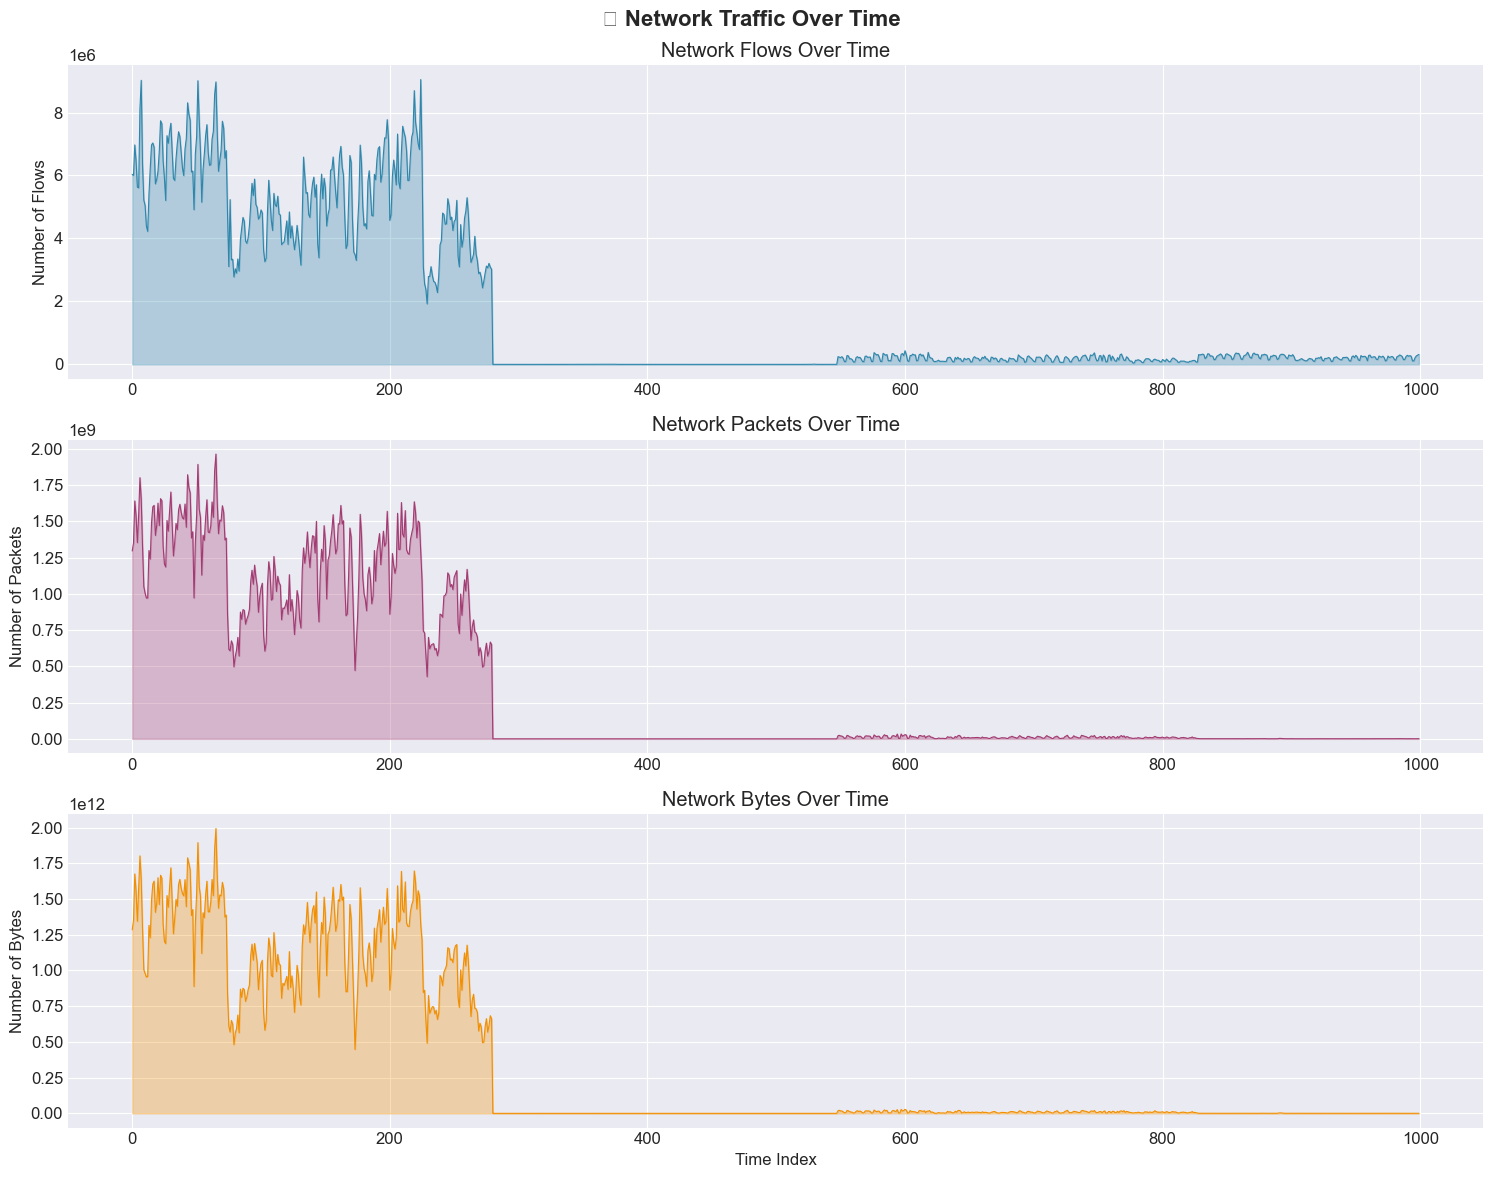

✅ Saved: visualization_3_timeseries.png


In [ ]:
# Visualization 3: Time Series of Network Traffic (using numpy)
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('📈 Network Traffic Over Time', fontsize=16, fontweight='bold')

# Plot first 1000 samples
n_samples = min(1000, matrix.shape[0])
time_indices = np.arange(n_samples)

# n_flows (column 1)
axes[0].plot(time_indices, matrix[:n_samples, 1], color='#2E86AB', linewidth=0.8)
axes[0].fill_between(time_indices, matrix[:n_samples, 1], alpha=0.3, color='#2E86AB')
axes[0].set_ylabel('Number of Flows')
axes[0].set_title('Network Flows Over Time')

# n_packets (column 2)
axes[1].plot(time_indices, matrix[:n_samples, 2], color='#A23B72', linewidth=0.8)
axes[1].fill_between(time_indices, matrix[:n_samples, 2], alpha=0.3, color='#A23B72')
axes[1].set_ylabel('Number of Packets')
axes[1].set_title('Network Packets Over Time')

# n_bytes (column 3)
axes[2].plot(time_indices, matrix[:n_samples, 3], color='#F18F01', linewidth=0.8)
axes[2].fill_between(time_indices, matrix[:n_samples, 3], alpha=0.3, color='#F18F01')
axes[2].set_ylabel('Number of Bytes')
axes[2].set_xlabel('Time Index')
axes[2].set_title('Network Bytes Over Time')

plt.tight_layout()
plt.savefig('visualization_3_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_3_timeseries.png")

## 5️⃣ Data Preprocessing

In [ ]:
# Extract features (drop id columns) - columns 1 to 18
X = matrix[:, 1:-1].astype(np.float32)

# Handle NaN and Inf values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix shape: {X.shape}")
print(f"Any NaN values: {np.isnan(X).any()}")
print(f"Any Inf values: {np.isinf(X).any()}")

Feature matrix shape: (150408, 18)
Any NaN values: False
Any Inf values: False


In [ ]:
# Log transform highly skewed features (n_flows, n_packets, n_bytes)
# These are at indices 0, 1, 2 in our feature matrix
skewed_indices = [0, 1, 2]  # n_flows, n_packets, n_bytes

X_transformed = X.copy()
for idx in skewed_indices:
    X_transformed[:, idx] = np.log1p(X[:, idx])

print("\n✅ Log transformation applied to: n_flows, n_packets, n_bytes")


✅ Log transformation applied to: n_flows, n_packets, n_bytes


In [ ]:
# Normalize features to [0, 1] range
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_transformed)

print(f"\n✅ Features normalized to [0, 1]")
print(f"Min values: {X_normalized.min(axis=0).round(3)}")
print(f"Max values: {X_normalized.max(axis=0).round(3)}")


✅ Features normalized to [0, 1]
Min values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max values: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6️⃣ Create Sliding Windows for Temporal Patterns

In [ ]:
def create_sliding_windows(data, window_size=10):
    """Create sliding windows for time series data."""
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i + window_size])
    return np.array(windows)

WINDOW_SIZE = 10
X_windows = create_sliding_windows(X_normalized, WINDOW_SIZE)

print(f"\n✅ Sliding windows created!")
print(f"Original shape: {X_normalized.shape}")
print(f"Windows shape: {X_windows.shape}")
print(f"  - {X_windows.shape[0]} samples")
print(f"  - {X_windows.shape[1]} time steps per sample")
print(f"  - {X_windows.shape[2]} features")


✅ Sliding windows created!
Original shape: (150408, 18)
Windows shape: (150399, 10, 18)
  - 150399 samples
  - 10 time steps per sample
  - 18 features


## 7️⃣ Define LSTM Autoencoder Model

In [ ]:
class Attention(nn.Module):
    """Attention mechanism for better temporal pattern recognition."""
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )
    
    def forward(self, encoder_outputs):
        attention_weights = F.softmax(self.attention(encoder_outputs), dim=1)
        context = torch.sum(attention_weights * encoder_outputs, dim=1)
        return context, attention_weights

class LSTMAutoencoder(nn.Module):
    """Fine-tuned LSTM Autoencoder with Attention."""
    def __init__(self, input_dim, hidden_dim=128, n_layers=2, dropout=0.3):
        super(LSTMAutoencoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # Bidirectional Encoder
        self.encoder = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True, 
                               dropout=dropout if n_layers > 1 else 0, bidirectional=True)
        self.attention = Attention(hidden_dim * 2)
        self.fc_compress = nn.Linear(hidden_dim * 2, hidden_dim)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, n_layers, batch_first=True,
                               dropout=dropout if n_layers > 1 else 0)
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, input_dim))
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        encoder_outputs, _ = self.encoder(x)
        context, _ = self.attention(encoder_outputs)
        compressed = self.layer_norm(F.relu(self.fc_compress(context)))
        decoder_input = compressed.unsqueeze(1).repeat(1, seq_len, 1)
        h_dec = compressed.unsqueeze(0).repeat(self.n_layers, 1, 1)
        c_dec = torch.zeros_like(h_dec)
        decoded, _ = self.decoder(decoder_input, (h_dec, c_dec))
        return self.output_layer(decoded)

print("✅ Fine-tuned LSTM Autoencoder with Attention defined!")


✅ Fine-tuned LSTM Autoencoder with Attention defined!


## 8️⃣ Train the Model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_tensor = torch.FloatTensor(X_windows)
train_size = int(0.8 * len(X_tensor))
val_size = len(X_tensor) - train_size
generator = torch.Generator().manual_seed(42)
train_data, val_data = torch.utils.data.random_split(
    TensorDataset(X_tensor, X_tensor), [train_size, val_size], generator=generator)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

input_dim = X_windows.shape[2]
model = LSTMAutoencoder(input_dim=input_dim, hidden_dim=128, n_layers=2, dropout=0.3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

print(f"\n✅ Model initialized! Parameters: {sum(p.numel() for p in model.parameters()):,}")


Using device: cuda

✅ Model initialized! Parameters: 886,611


In [ ]:
EPOCHS, PATIENCE, GRAD_CLIP = 50, 10, 1.0
train_losses, val_losses = [], []
best_val_loss, patience_counter, best_model_state = float('inf'), 0, None

print("\n🚀 Starting training...\n")
for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_train_loss += loss.item()
    
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            epoch_val_loss += criterion(model(batch_x), batch_y).item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss, patience_counter = avg_val_loss, 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train: {avg_train_loss:.6f}, Val: {avg_val_loss:.6f}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping at epoch {epoch+1}")
        break

if best_model_state: model.load_state_dict(best_model_state)
print(f"\n✅ Training complete! Best Val Loss: {best_val_loss:.6f}")



🚀 Starting training...

Epoch [5/50] Train: 0.001250, Val: 0.000565
Epoch [10/50] Train: 0.001091, Val: 0.000419
Epoch [15/50] Train: 0.001022, Val: 0.000331
Epoch [20/50] Train: 0.000981, Val: 0.000313
Epoch [25/50] Train: 0.000959, Val: 0.000273
Epoch [30/50] Train: 0.000941, Val: 0.000267
Epoch [35/50] Train: 0.000932, Val: 0.000249
Epoch 00039: reducing learning rate of group 0 to 5.0000e-04.
Epoch [40/50] Train: 0.000907, Val: 0.000207
Epoch [45/50] Train: 0.000901, Val: 0.000209
Epoch [50/50] Train: 0.000899, Val: 0.000198

✅ Training complete! Best Val Loss: 0.000190


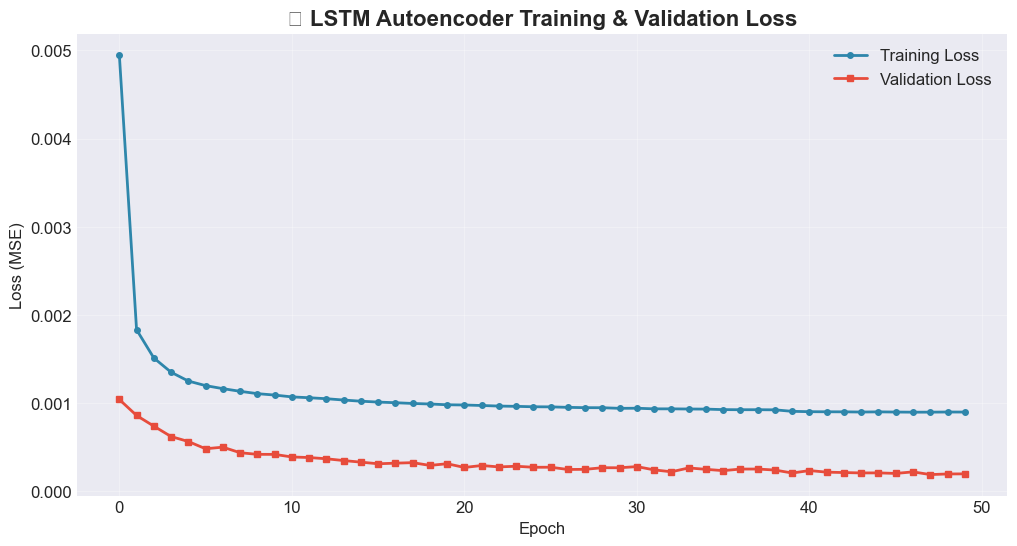

✅ Saved: visualization_4_training_loss.png


In [ ]:
# Visualization 4: Combined Training and Validation Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_losses, color='#2E86AB', linewidth=2, marker='o', markersize=4, label='Training Loss')
plt.plot(val_losses, color='#E74C3C', linewidth=2, marker='s', markersize=4, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('📉 LSTM Autoencoder Training & Validation Loss', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('visualization_4_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_4_training_loss.png")

## 9️⃣ Calculate Anomaly Scores

In [ ]:
# Calculate anomaly scores in batches to avoid OOM Error
model.eval()
BATCH_SIZE = 256  # Smaller batch size for inference

# Create dataloader for full dataset
full_dataset = TensorDataset(X_tensor, X_tensor)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_errors = []
print("Calculating anomaly scores in batches...")

with torch.no_grad():
    for batch_idx, (batch_x, batch_y) in enumerate(full_loader):
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)
        batch_errors = torch.mean((batch_x - reconstructed) ** 2, dim=(1, 2))
        all_errors.append(batch_errors.cpu())
        
        if (batch_idx + 1) % 100 == 0:
            print(f"  Processed batch {batch_idx+1}/{len(full_loader)}")

anomaly_scores = torch.cat(all_errors).numpy()

print(f"\n✅ Anomaly scores calculated!")
print(f"Scores shape: {anomaly_scores.shape}")
print(f"Min score: {anomaly_scores.min():.6f}")
print(f"Max score: {anomaly_scores.max():.6f}")
print(f"Mean score: {anomaly_scores.mean():.6f}")

Calculating anomaly scores in batches...
  Processed batch 100/588
  Processed batch 200/588
  Processed batch 300/588
  Processed batch 400/588
  Processed batch 500/588

✅ Anomaly scores calculated!
Scores shape: (150399,)
Min score: 0.000027
Max score: 0.016943
Mean score: 0.000197


In [ ]:
# Set threshold (top 5% as anomalies)
PERCENTILE = 95
threshold = np.percentile(anomaly_scores, PERCENTILE)
is_anomaly = anomaly_scores > threshold

print(f"\n🎯 Anomaly Detection Results:")
print(f"="*40)
print(f"Threshold (P{PERCENTILE}): {threshold:.6f}")
print(f"Total samples: {len(anomaly_scores):,}")
print(f"Normal samples: {(~is_anomaly).sum():,} ({100*(~is_anomaly).mean():.1f}%)")
print(f"Anomalies detected: {is_anomaly.sum():,} ({100*is_anomaly.mean():.1f}%)")


🎯 Anomaly Detection Results:
Threshold (P95): 0.000474
Total samples: 150,399
Normal samples: 142,879 (95.0%)
Anomalies detected: 7,520 (5.0%)


## 🔟 Visualize Anomaly Detection Results

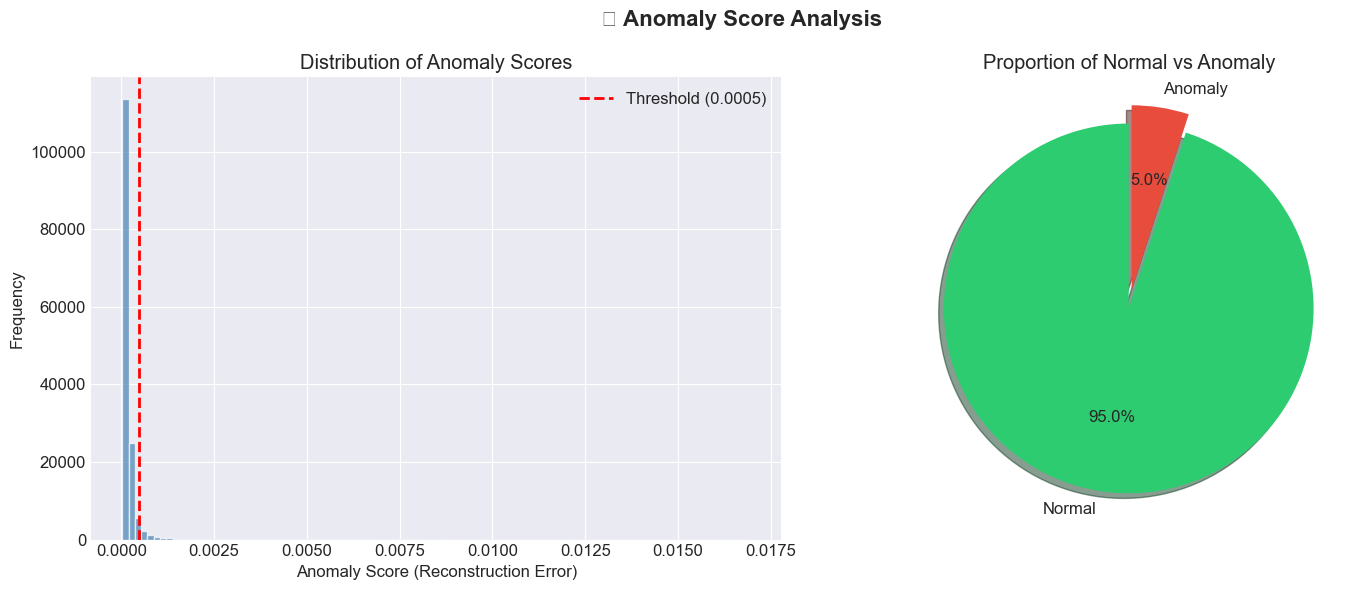

✅ Saved: visualization_5_anomaly_distribution.png


In [ ]:
# Visualization 5: Anomaly Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🔍 Anomaly Score Analysis', fontsize=16, fontweight='bold')

axes[0].hist(anomaly_scores, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
axes[0].set_xlabel('Anomaly Score (Reconstruction Error)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Anomaly Scores')
axes[0].legend()

sizes = [(~is_anomaly).sum(), is_anomaly.sum()]
axes[1].pie(sizes, explode=(0, 0.1), labels=['Normal', 'Anomaly'], colors=['#2ECC71', '#E74C3C'],
            autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion of Normal vs Anomaly')

plt.tight_layout()
plt.savefig('visualization_5_anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_5_anomaly_distribution.png")

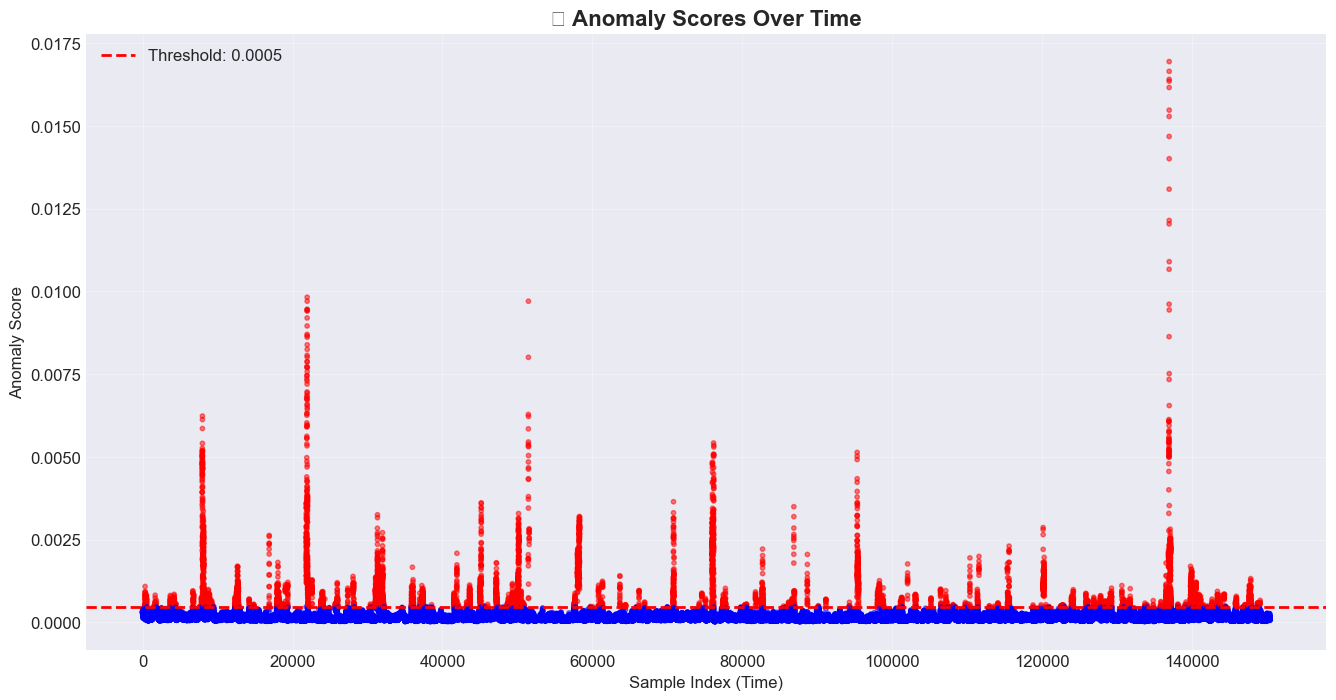

✅ Saved: visualization_6_anomaly_timeline.png


In [ ]:
# Visualization 6: Anomaly Scores Over Time
plt.figure(figsize=(16, 8))
colors = ['red' if a else 'blue' for a in is_anomaly]
plt.scatter(range(len(anomaly_scores)), anomaly_scores, c=colors, alpha=0.5, s=10)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.xlabel('Sample Index (Time)')
plt.ylabel('Anomaly Score')
plt.title('⏰ Anomaly Scores Over Time', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('visualization_6_anomaly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_6_anomaly_timeline.png")

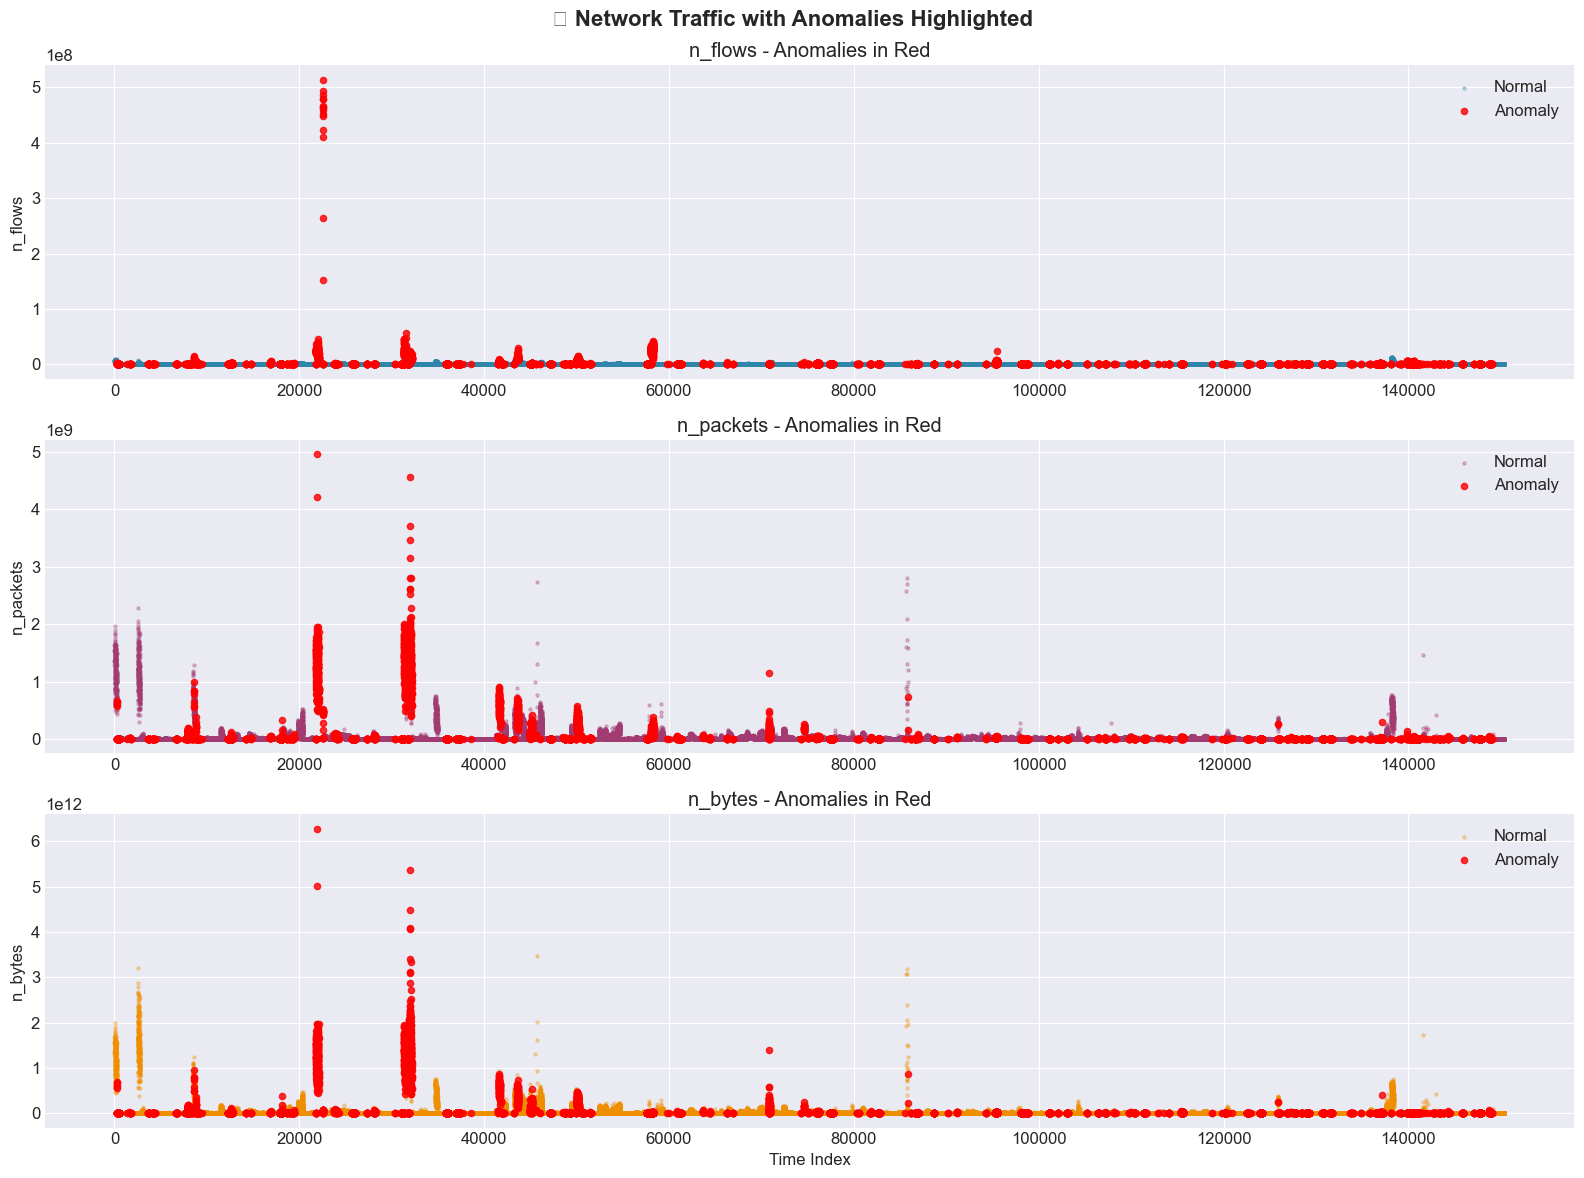

✅ Saved: visualization_7_traffic_anomalies.png


In [ ]:
# Visualization 7: Network Traffic with Anomalies Highlighted (using numpy)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('🚨 Network Traffic with Anomalies Highlighted', fontsize=16, fontweight='bold')

# Use original matrix (first len(anomaly_scores) rows)
n_samples = len(anomaly_scores)
features_info = [(1, 'n_flows', '#2E86AB'), (2, 'n_packets', '#A23B72'), (3, 'n_bytes', '#F18F01')]

for idx, (col_idx, feature_name, color) in enumerate(features_info):
    ax = axes[idx]
    data = matrix[:n_samples, col_idx]
    
    # Normal points
    normal_mask = ~is_anomaly
    ax.scatter(np.where(normal_mask)[0], data[normal_mask], c=color, alpha=0.3, s=5, label='Normal')
    
    # Anomaly points
    ax.scatter(np.where(is_anomaly)[0], data[is_anomaly], c='red', alpha=0.8, s=20, label='Anomaly')
    
    ax.set_ylabel(feature_name)
    ax.legend(loc='upper right')
    ax.set_title(f'{feature_name} - Anomalies in Red')

axes[2].set_xlabel('Time Index')
plt.tight_layout()
plt.savefig('visualization_7_traffic_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_7_traffic_anomalies.png")

## 1️⃣1️⃣ Save Results

In [ ]:
# Create DataFrame for saving (only now, for export)
n_samples = len(anomaly_scores)
df = pd.DataFrame(matrix[:n_samples], columns=COLUMN_NAMES)
df['anomaly_score'] = anomaly_scores
df['is_anomaly'] = is_anomaly

# Save to CSV
df.to_csv('anomaly_detection_results.csv', index=False)
print("✅ Saved: anomaly_detection_results.csv")

# Save model
torch.save({'model_state_dict': model.state_dict(), 'threshold': threshold,
            'scaler_min': scaler.data_min_, 'scaler_max': scaler.data_max_}, 'lstm_autoencoder_model.pth')
print("✅ Saved: lstm_autoencoder_model.pth")

✅ Saved: anomaly_detection_results.csv
✅ Saved: lstm_autoencoder_model.pth


In [ ]:
# Show sample results
print("\n📊 Sample Results (First 10 rows):")
display_cols = ['id_time', 'n_flows', 'n_packets', 'n_bytes', 'anomaly_score', 'is_anomaly']
print(df[display_cols].head(10))

print("\n🚨 Sample Detected Anomalies:")
print(df[df['is_anomaly']][display_cols].head(10))


📊 Sample Results (First 10 rows):
   id_time    n_flows     n_packets       n_bytes  anomaly_score  is_anomaly
0      0.0  6037276.0  1.296003e+09  1.283605e+12       0.000332       False
1      1.0  6003202.0  1.352725e+09  1.352567e+12       0.000325       False
2      2.0  6970395.0  1.641867e+09  1.675324e+12       0.000360       False
3      3.0  6456615.0  1.538404e+09  1.553394e+12       0.000308       False
4      4.0  5630980.0  1.353925e+09  1.343859e+12       0.000287       False
5      5.0  5608853.0  1.545271e+09  1.563984e+12       0.000285       False
6      6.0  8109116.0  1.802092e+09  1.801722e+12       0.000300       False
7      7.0  9022666.0  1.651514e+09  1.634615e+12       0.000307       False
8      8.0  6348357.0  1.331712e+09  1.293487e+12       0.000288       False
9      9.0  5218956.0  1.051143e+09  1.005776e+12       0.000292       False

🚨 Sample Detected Anomalies:
     id_time    n_flows    n_packets       n_bytes  anomaly_score  is_anomaly
276    276

## 1️⃣2️⃣ Summary for Presentation

In [ ]:
print("\n" + "="*70)
print("           📊 ANOMALY DETECTION SUMMARY FOR PRESENTATION")
print("="*70)
print(f"""
🎯 PROJECT: AI-Augmented Observability System for ISP
📊 DATASET: CESNET Time Series 24 (Network Traffic)
🤖 MODEL: LSTM Autoencoder (Unsupervised)

📈 DATA STATISTICS:
   • Total samples analyzed: {len(anomaly_scores):,}
   • Features used: {len(FEATURE_NAMES)}
   • Time window size: {WINDOW_SIZE} steps

🔍 DETECTION RESULTS:
   • Anomaly threshold (P{PERCENTILE}): {threshold:.6f}
   • Normal traffic: {(~is_anomaly).sum():,} ({100*(~is_anomaly).mean():.1f}%)
   • Anomalies detected: {is_anomaly.sum():,} ({100*is_anomaly.mean():.1f}%)

📁 OUTPUT FILES:
   • anomaly_detection_results.csv (For Grafana)
   • lstm_autoencoder_model.pth (Trained model)
   • 7 visualization images (For presentation)

✅ KEY TAKEAWAYS:
   1. Model learns "normal" network patterns
   2. High reconstruction error = anomaly
   3. Top {100-PERCENTILE}% unusual patterns flagged as anomalies
   4. Ready for Grafana dashboard integration
""")
print("="*70)
print("\n🎉 PIPELINE COMPLETE!")


           📊 ANOMALY DETECTION SUMMARY FOR PRESENTATION

🎯 PROJECT: AI-Augmented Observability System for ISP
📊 DATASET: CESNET Time Series 24 (Network Traffic)
🤖 MODEL: LSTM Autoencoder (Unsupervised)

📈 DATA STATISTICS:
   • Total samples analyzed: 150,399
   • Features used: 18
   • Time window size: 10 steps

🔍 DETECTION RESULTS:
   • Anomaly threshold (P95): 0.000474
   • Normal traffic: 142,879 (95.0%)
   • Anomalies detected: 7,520 (5.0%)

📁 OUTPUT FILES:
   • anomaly_detection_results.csv (For Grafana)
   • lstm_autoencoder_model.pth (Trained model)
   • 7 visualization images (For presentation)

✅ KEY TAKEAWAYS:
   1. Model learns "normal" network patterns
   2. High reconstruction error = anomaly
   3. Top 5% unusual patterns flagged as anomalies
   4. Ready for Grafana dashboard integration


🎉 PIPELINE COMPLETE!
